https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-01-01.%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80-%EC%98%88%EC%A0%9C-2

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes

# 데이터 로드
diabetes = load_diabetes()

# DataFrame 변환
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# 타겟 추가
df['target'] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
print(df.shape)
print(df.info())

(442, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


In [3]:
df.corr()['target'].sort_values(ascending=False)

,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# X, y 분리
X = df.drop('target', axis=1)
y = df['target']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델 생성
model = LinearRegression()

# 학습
model.fit(X_train, y_train)

# 예측
pred = model.predict(X_test)

print("기울기:", model.coef_)
print("절편:", model.intercept_)

기울기: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
절편: 151.34560453985995


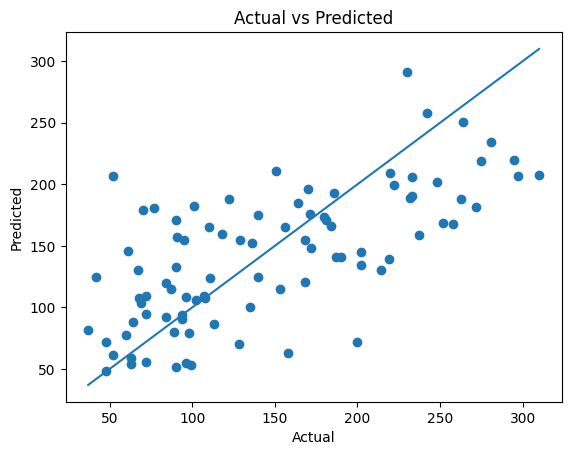

In [5]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# 기준선 (완벽한 예측)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# MSE #평균제곱오차
mse = mean_squared_error(y_test, pred)
 
# RMSE # 평균 제곱오차에 루트를 씌운거
rmse = np.sqrt(mse)

# R²
r2 = r2_score(y_test, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 2900.193628493482
RMSE: 53.85344583676593
R2: 0.4526027629719195
